In [99]:
# Supressing warnings
import warnings
warnings.filterwarnings('ignore')

In [100]:
# Importing libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso

import matplotlib.pyplot as plt
import seaborn as sns

### Step 1: Read and explore data

In [101]:
data = pd.read_csv('auto-mpg.csv')

<b><u>Features in data set</u></b>

cylinders: contains the number of cylinders present in the car

displacement: contains the Displacement of the car

horsepower: contains the Horsepower of the car

weight: contains the weight of the car

acceleration: contains the Acceleration of the car

model_year: contains the model year of the car

origin: contains the origin country which car belong to

car_name: contains the name of the car(Brand-Model-Variant)


predict Miles per Gallon

mpg: contains the fuel consumption value(in Miles per Gallon) for car

In [102]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [103]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


### Step 2: Data cleaning/missing value imputation

In [104]:
# converting weight to float as it is continuous type
data.weight = data.weight.astype('float')

In [105]:
# Converting horsepower to float type
data.horsepower = data.horsepower.str.strip()
data.loc[data.horsepower == '?', 'horsepower'] = np.nan
data.horsepower = data.horsepower.astype('float')

In [106]:
print(f"horsepower column has {data.horsepower.isna().sum()} missing values")

horsepower column has 6 missing values


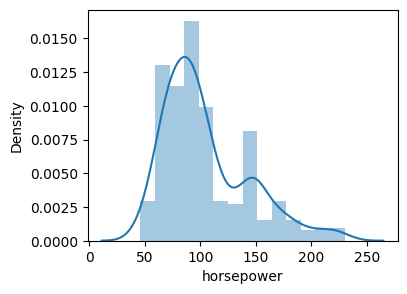

In [107]:
fig = plt.figure(figsize=(4, 3))
sns.distplot(data.horsepower, kde=True)
plt.show()

horsepower distribution seem skewed

In [108]:
avg_hp = data.horsepower.mean()
median_hp = data.horsepower.median()
print("right skewed" if avg_hp > median_hp else "left skewed")

right skewed


In [109]:
# imputing missing value with median
data.loc[data.horsepower.isna(), 'horsepower'] = median_hp

In [110]:
data.describe(include='all')

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,305
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ford pinto
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
mean,23.514573,5.454774,193.425879,104.304020,2970.424623,15.568090,76.010050,1.572864,NaN
std,7.815984,1.701004,104.269838,38.222625,846.841774,2.757689,3.697627,0.802055,NaN
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,NaN
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,1.000000,NaN
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000,NaN
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,2.000000,NaN


In [111]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


### Step 3: Univariate analysis

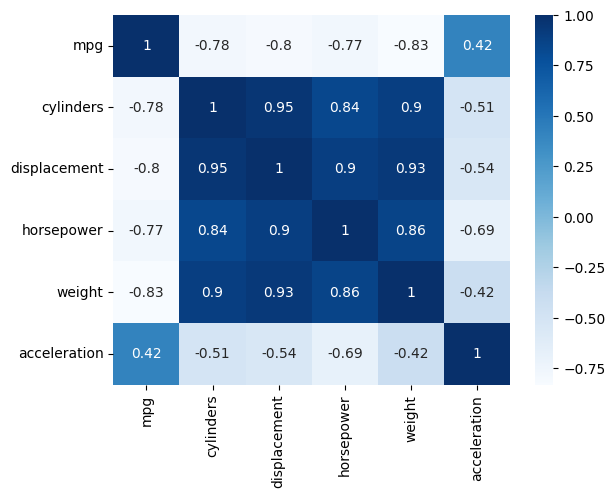

In [112]:
# Correlation of output with numerical columns
numerical_columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']
corr_matrix = data[numerical_columns].corr()

# plotting the correlation matrix
fig = plt.figure()
sns.heatmap(corr_matrix, annot=True, cmap='Blues')
plt.show()

### Step 4: Create features and scale the data

In [113]:
data = pd.get_dummies(data, columns=['model year', 'origin'])
dummy_columns = ['model year_70', 'model year_71',
       'model year_72', 'model year_73', 'model year_74', 'model year_75',
       'model year_76', 'model year_77', 'model year_78', 'model year_79',
       'model year_80', 'model year_81', 'model year_82', 'origin_1',
       'origin_2', 'origin_3']
data[dummy_columns] = data[dummy_columns].astype('int')

In [114]:
# dropping unwanted data
data.drop(columns=['car name'], inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   mpg            398 non-null    float64
 1   cylinders      398 non-null    int64  
 2   displacement   398 non-null    float64
 3   horsepower     398 non-null    float64
 4   weight         398 non-null    float64
 5   acceleration   398 non-null    float64
 6   model year_70  398 non-null    int32  
 7   model year_71  398 non-null    int32  
 8   model year_72  398 non-null    int32  
 9   model year_73  398 non-null    int32  
 10  model year_74  398 non-null    int32  
 11  model year_75  398 non-null    int32  
 12  model year_76  398 non-null    int32  
 13  model year_77  398 non-null    int32  
 14  model year_78  398 non-null    int32  
 15  model year_79  398 non-null    int32  
 16  model year_80  398 non-null    int32  
 17  model year_81  398 non-null    int32  
 18  model year

### Step 5: Splitting and scaling data

Training: 80%
Testing: 20%

In [116]:
from sklearn.model_selection import train_test_split

# splitting the data
x_train, x_test = train_test_split(data, train_size=0.80, test_size=0.20, random_state=0)
y_train = x_train.pop('mpg')
y_test = x_test.pop('mpg')

Scaling the data

In [119]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
target_variables = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']
x_train[target_variables] = scaler.fit_transform(x_train[target_variables])
x_test[target_variables] = scaler.transform(x_test[target_variables])

In [ ]:
x_train.describe()

,cylinders,displacement,horsepower,weight,acceleration,model year_70,model year_71,model year_72,model year_73,model year_74,...,model year_76,model year_77,model year_78,model year_79,model year_80,model year_81,model year_82,origin_1,origin_2,origin_3
count,3.180000e+02,3.180000e+02,3.180000e+02,3.180000e+02,3.180000e+02,318.000000,318.000000,318.000000,318.000000,318.000000,...,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000
mean,5.167076e-17,-5.586028e-18,-8.379042e-18,8.658343e-17,-8.099740e-17,0.056604,0.075472,0.066038,0.103774,0.066038,...,0.088050,0.072327,0.103774,0.069182,0.075472,0.072327,0.081761,0.613208,0.182390,0.204403
std,1.001576e+00,1.001576e+00,1.001576e+00,1.001576e+00,1.001576e+00,0.231448,0.264567,0.248739,0.305447,0.248739,...,0.283815,0.259437,0.305447,0.254164,0.264567,0.259437,0.274432,0.487783,0.386774,0.403900
min,-1.439889e+00,-1.206235e+00,-1.539074e+00,-1.557528e+00,-2.834531e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-8.528574e-01,-8.773955e-01,-7.634178e-01,-8.853486e-01,-6.098147e-01,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-8.528574e-01,-4.218919e-01,-2.686030e-01,-1.669553e-01,-5.363571e-02,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,1.495269e+00,6.839831e-01,5.739196e-01,7.084477e-01,5.581612e-01,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,1.495269e+00,2.564458e+00,3.382328e+00,2.579233e+00,3.394674e+00,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Step 6: Train and evaluate model

Lasso / L1 Regularization

In [ ]:
# hyperparameter : alph - <= 10

In [ ]:
# Try with different values of regularization parameter alpha
lasso = Lasso(alpha=0.1) # alpha must be a non-negative float i.e. [0, inf)
lasso.fit(x_train, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [124]:
lasso.coef_

array([-0.        , -0.        , -1.32346762, -3.92962898,  0.16228359,
       -0.        , -0.        , -0.        , -1.16025939, -0.        ,
       -0.        , -0.        ,  0.        ,  0.        ,  0.99050101,
        5.57077232,  3.91827143,  4.48892226, -1.42347901,  0.        ,
        0.31942101])

In [123]:
for i in range(len(x_train.columns)):
    print(f"Lasso coefficient for {x_train.columns[i]} is {lasso.coef_[i]}.")

Lasso coefficient for cylinders is -0.0.
Lasso coefficient for displacement is -0.0.
Lasso coefficient for horsepower is -1.32346762349825.
Lasso coefficient for weight is -3.9296289788577687.
Lasso coefficient for acceleration is 0.16228359283584567.
Lasso coefficient for model year_70 is -0.0.
Lasso coefficient for model year_71 is -0.0.
Lasso coefficient for model year_72 is -0.0.
Lasso coefficient for model year_73 is -1.1602593936983276.
Lasso coefficient for model year_74 is -0.0.
Lasso coefficient for model year_75 is -0.0.
Lasso coefficient for model year_76 is -0.0.
Lasso coefficient for model year_77 is 0.0.
Lasso coefficient for model year_78 is 0.0.
Lasso coefficient for model year_79 is 0.9905010147816775.
Lasso coefficient for model year_80 is 5.570772322851038.
Lasso coefficient for model year_81 is 3.9182714346751113.
Lasso coefficient for model year_82 is 4.488922259251746.
Lasso coefficient for origin_1 is -1.4234790076606434.
Lasso coefficient for origin_2 is 0.0.
La

In [125]:
from sklearn.metrics import r2_score
y_test_pred = lasso.predict(x_test)
r2_score(y_test, y_test_pred)

0.8105876167319835

Ridge / L2 Regularization

In [126]:
ridge = Ridge(alpha=0.1)
ridge.fit(x_train, y_train)

,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [127]:
ridge.coef_

array([ 0.01255591,  1.90669441, -0.87344348, -5.34078641,  0.42753129,
       -3.45241012, -2.11370689, -2.70537249, -3.64593079, -1.55966555,
       -2.05707193, -1.62048155,  0.24705153, -0.37743785,  1.38790963,
        6.1479312 ,  4.58513291,  5.16405189, -1.88634562,  0.89700632,
        0.9893393 ])

In [128]:
for i in range(len(x_train.columns)):
    print(f"Ridge coefficient for {x_train.columns[i]} is {ridge.coef_[i]}.")

Ridge coefficient for cylinders is 0.012555913661362163.
Ridge coefficient for displacement is 1.906694414501197.
Ridge coefficient for horsepower is -0.8734434754144134.
Ridge coefficient for weight is -5.340786414871312.
Ridge coefficient for acceleration is 0.4275312904878873.
Ridge coefficient for model year_70 is -3.4524101166968073.
Ridge coefficient for model year_71 is -2.1137068889934723.
Ridge coefficient for model year_72 is -2.705372488543871.
Ridge coefficient for model year_73 is -3.6459307925154603.
Ridge coefficient for model year_74 is -1.5596655451805095.
Ridge coefficient for model year_75 is -2.057071932746777.
Ridge coefficient for model year_76 is -1.620481550126956.
Ridge coefficient for model year_77 is 0.24705152978382705.
Ridge coefficient for model year_78 is -0.3774378496518305.
Ridge coefficient for model year_79 is 1.3879096349682223.
Ridge coefficient for model year_80 is 6.147931202690611.
Ridge coefficient for model year_81 is 4.585132911013447.
Ridge c

In [129]:
y_test_pred = ridge.predict(x_test)
r2_score(y_test, y_test_pred)

0.8416853906187856